In [1]:
import os
os.environ["PYTHON_JULIACALL_AUTOLOAD_IPYTHON_EXTENSION"] = "no"

import matplotlib as mpl
font = {'family' : 'sans',
        'size'   : 12}

mpl.rc('font', **font)
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.ticker import MultipleLocator, LogLocator, MaxNLocator
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

from utils.load_grid import latexify, descend_get, M_earth, R_earth, M_sun, R_jupiter

import numpy as np
from scipy.integrate import cumulative_simpson
from copy import deepcopy
import pandas as pd
import os
import json
import toml
from glob import glob
from scipy.interpolate import PchipInterpolator

from scipy.stats import gaussian_kde



import pandas as pd
from cmcrameri import cm

DPI=400

# THESIS_DIR = "/home2/p321409/Projects/thesis_pipeline"
# SIM_DIR = "data/scratch/"

# THESIS_DIR = "/home/harrison/Projects/thesis_pipeline"
# SIM_DIR = "data/"

THESIS_DIR = "/data/hen28/Projects/thesis_pipeline"
SIM_DIR = "data/bayesopt_recent/"



In [41]:

age_min = 1e5
age_max = 4e9

gas_list = ["H2O", "H2", "CO2", "CO", "CH4", "N2", "NH3", "H2S", "SO2"]


# Standard plotting colours
preset_colours = {
    # Default colour
    '_fallback': '#ff00ff',
    # Volatile gases
    'H2O': '#027FB1',
    'CO2': '#D24901',
    'H2': '#008C01',
    'CH4': '#C720DD',
    'CO': '#D1AC02',
    'N2': '#870036',
    'S2': '#FF8FA1',
    'SO2': '#00008B',
    'H2S': '#2eff90',
    'NH3': '#675200',
    # Volatile elements
    'H': '#0000cc',
    'C': '#ff0000',
    'O': '#88bb22',
    'N': '#ffaa00',
    'S': '#ff22ff',
    'P': '#33ccff',
    # refractory elements
    'Fe': '#888888',
    'Si': '#aa2277',
    'Mg': '#996633',
    'Na': '#ccff00',
    # GLobal energy fluxes
    'OLR': '#dc143c',
    'ASF': '#4169e1',
    'sct': '#2e8b57',
    'tidal': '#daa520',
    'radio': '#C720DD',
    'star': '#FF8FA1',
    # Atmosphere energy fluxes (copied from AGNI)
    'flux_r': '#c0c0c0',
    'flux_n': '#000000',
    'flux_c': '#6495ed',
    'flux_t': '#ff4400',
    'flux_o': '#66CD00',
    'flux_p': '#ecb000',
    # Model components
    'atm': '#444444',
    'int': '#ff7f0e',
    'core': '#aa3077',
    'atm_bkg': '#f2faff',
    'int_bkg': '#fffaf2',
    'cor_bkg': '#efefef',
    # Clouds and aerosols
    'cloud': '#027FB1',
    'frsoot': '#876e44',
    'soot': '#63401a',
    'agsoot': '#251607',
    'nitrate': '#ffaa00',
    'ash': '#970505',
    'sulph': '#ff22ff',
    'biogenic': '#33ccff',
    'bioms1': '#33ccaa',
    'delta': '#6a9064',
    'dustdiv1': '#fcfcd7',
    'dustdiv2': '#fbfca1',
    'dustdiv3': '#f6f873',
    'dustdiv4': '#fcff5d',
    'dustdiv5': '#fcff33',
    'dustdiv6': '#fbff21',
    'naclflm': '#fca1ff',
    'nacljet': '#ee29f5',
}


def get_var_props(key):
    """Get plot properties for key

    Arguments
    ----------
    - key, str

    Returns
    ----------
    - scale, float
    - yscl, str
    - ylim, list
    - ytck, list
    - ylbl, str
    """

    scale = 1
    yscl = "linear"
    ylim = None
    ytck = None
    ylbl = key

    # Observables
    # ---------------------
    if key == "Time":
        scale = 1
        ylbl = "Time\n[yr]"
        yscl = "log"
    elif key == "M_planet":
        scale = M_earth
        ytck  = [1, 2, 3]
        ylim  = [0.8, 3.2]
        ylbl  = "Mass\n" + r"[M$_{\oplus}$]"
    elif key == "R_obs":
        scale = R_earth
        ytck = [1, 1.5, 2]
        ylim = [0.6, 2.4]
        ylbl  = r"R$_{\rm obs}$" + "\n" + r"[R$_{\oplus}$]"
    elif key == "g_obs":
        scale = 1.0
        ytck = [8.0, 12.0, 16.0, 20.0]
        ylim = [5.0, 22.1]
        ylbl  = r"g$_{\rm obs}$" + "\n" + r"[m/s$^2]$"
    elif key == "T_obs":
        scale = 1.0
        ylim = [0, 1000]
        ylbl  = r"T$_{\rm obs}$" + "\n[K]"
        ytck = [0, 300, 600, 900]
    elif key == "atm_kg_per_mol":
        scale = 1e-3
        ylim = [8, 40]
        ylbl = r"$\mu_{\rm obs}$"+"\n[g/mol]"
        ytck = [5, 15, 25, 35]
    elif key in ["C/O_atm", "S/O_atm", "O/H_atm"]:
        scale = 1
        yscl = "log"
        ylim = [2e-2, 2e1]
        ylbl = key.split("_")[0]
    elif key.endswith("_vmr"):
        scale = 1e-2
        ylbl = latexify(key.split("_")[0]) + "\n[%]"
        ylim = [-2, 102.0]
        ytck = [0, 25, 50, 75]
    elif key == "P_surf":
        scale = 1e3
        ylim = [0, 1e3]
        ylbl = r"P$_{\rm surf}$" + "\n[kbar]"
        yscl = "symlog"
        ytck = [1, 10, 100, 1000]
    elif key == "Phi_global":
        scale = 1e-2
        ylim = [-5, 105.0]
        ylbl = "Melt\nfrac.\n[%]"
        ytck = [0, 40, 80,]
    elif key == "T_surf":
        scale = 1.0
        ylim = [1000, 3500]
        ylbl  = r"T$_{\rm surf}$" + "\n[K]"
        # ytck = [0.5, 1.0, 1.5, 2.0]

    # Parameters
    # ---------------------
    elif key == "interior_energetics.boundary.T_p_0":
        scale = 1.0
        ylbl  = r"T${\rm _{pot}^{ini}}$" + "\n[K]"
        ylim = [1500, 3500]
        # ytck = [2.0, 2.5, 3.0, 3.5, 4.0]
    elif key == "params.stop.time.maximum":
        ylbl  = "Age\n" + r"[yr]"
        yscl = "log"
        ylim = [age_min / 5, age_max * 5]
    elif key == "planet.semimajoraxis":
        ylbl  = "SMA\n" + r"[AU]"
        ytck = [0, 0.05, .1, 0.15, 0.2, 0.25]
    elif key == "planet.mass_tot":
        ylbl  = r"$M^{\rm ini}$" +"\n"+ r"/M$_{\oplus}$"
        ytck  = [1, 2, 3]
        ylim  = [0.8, 3.2]
    elif key == 'interior_struct.core_frac':
        scale = 1e-2
        ylbl = "Core\n[%]"
        ytck = [40, 50, 60]
        ylim = [30, 70]
    elif key == 'outgas.fO2_shift_IW':
        ylbl = r"$f{\rm O_2}$" + "\n" + r"[$\Delta {\rm IW}$]"
        ytck = [-4, -2, 0, 2, 4]
        ylim = [-4.5, 4.5]
    elif key == "planet.elements.H_budget": # ppmw
        scale = 1.0
        yscl = "log"
        ylbl = "Initial\n" + r"H$_{\rm ppmw}$"
        ylim = [1e3, 2e4]
    elif key == "planet.elements.C_budget": # C/H
        ylbl = "Initial\nC/H"
        ytck = [0, 2, 4]
        ylim = [-0.1, 4.5]
    elif key == "planet.elements.S_budget": # S/H
        ylbl  = "Initial\nS/H"
        ytck = [0, 2, 4]
        ylim = [-0.1, 4.5]
    elif key == "objective":
        ylbl = "Objective"

    return scale, yscl, ylim, ytck, ylbl

In [3]:
%matplotlib inline
# %config InlineBackend.figure_format='retina'

# %matplotlib widget

In [4]:
def get_bo_run(output_dir):

    output_dir = os.path.abspath(output_dir)
    # print("    Reading BO run from", output_dir)

    # check folder exists
    if not os.path.isdir(output_dir):
        print(f"Folder {output_dir} does not exist.")
        return None

    # Read BO config file
    config_path = os.path.join(output_dir, "copy.infer.toml")
    infer_conf = toml.load(config_path)
    obs = infer_conf['observables']
    prs = infer_conf['parameters']

    # Extract log of BO run
    if not os.path.isfile(os.path.join(output_dir, "logs.csv")):
        print(f"Log file not found in {output_dir}.")
        return None
    fpath = os.path.join(output_dir, "logs.csv")
    log = []
    best_obj = -np.inf
    with open(fpath, 'r') as f:
        for line in f.readlines():
            if '{' not in line:
                continue
            line = line.replace("'", '"').replace("None", "1.0")[1:-2]
            json_line = json.loads(line) # parse json into dict
            log.append(json_line)

            if json_line['y_value'] > best_obj:
                best_obj = json_line['y_value']

    # Mark best worker
    is_best = np.full(len(log), False, dtype=bool)
    for i, run in enumerate(log):
        if run['y_value'] == best_obj:
            is_best[i] = True
    print("        best worker:", np.where(is_best)[0], "with y =", best_obj)

    # For each worker, read helpfile
    helps = []
    confs = []
    for run in log:
        wk = run['worker']
        id = run['task_id']

        help_path = os.path.join(output_dir, "workers", f"w_{wk}", f"i_{id}", "runtime_helpfile.csv")
        if not os.path.isfile(help_path):
            print(f"Helpfile not found for worker {wk}, task {id}.")
            continue
        helps.append(pd.read_csv(help_path, delimiter=r"\s+"))

        conf_path = os.path.join(output_dir, "workers", f"w_{wk}", f"i_{id}", "input.toml")
        confs.append(toml.load(conf_path))

    # Package into dict
    bo_run = {
        "config": infer_conf,
        "log": log,
        "helps": helps,
        "confs": confs,
        "obs": obs,
        "prs": prs,
        "is_best": is_best,
    }
    return bo_run

def get_gt_run(gt_dir):

    # Read GT config file
    config_path = os.path.join(gt_dir, "init_coupler.toml")
    gt_conf = toml.load(config_path)

    # Read GT helpfile
    help_path = os.path.join(gt_dir, "runtime_helpfile.csv")
    help_path = os.path.abspath(help_path)
    print("Reading GT helpfile from", help_path)
    gt_help = pd.read_csv(help_path, delimiter=r"\s+")

    gt_run = {
        "config": gt_conf,
        "help": gt_help,
    }
    return gt_run

bo_suffixes = ('sn', 'se', 'tr')

# Read ground truth config and results
ground_truth  = {suf: get_gt_run(f"{SIM_DIR}/bayesopt_{suf}/") for suf in bo_suffixes}

# Plotting parameters
bo_cols = {
    'sn': 'tab:blue',
    'se': 'tab:orange',
    'tr': 'tab:green'
}
bo_tits = {
    'sn': 'Sub-Neptune',
    'se': 'Super-Earth',
    'tr': 'Terrestrial'
}


Reading GT helpfile from /data/hen28/Projects/proteus_analysis/data/bayesopt_recent/bayesopt_sn/runtime_helpfile.csv
Reading GT helpfile from /data/hen28/Projects/proteus_analysis/data/bayesopt_recent/bayesopt_se/runtime_helpfile.csv
Reading GT helpfile from /data/hen28/Projects/proteus_analysis/data/bayesopt_recent/bayesopt_tr/runtime_helpfile.csv


In [5]:
# Read inference results

def load_bo_data(controls):
    bo_data = {}
    for run in glob("bayesopt_infer_*/", root_dir=SIM_DIR):
        print(f"Found {run}", end='')

        parts = run.replace("/","").split("_")[2:]
        suf = parts[0]
        ker = parts[1]
        acq = parts[2]
        wrk = parts[3]
        stp = parts[4]

        skip = False
        skip |= ("suf" in controls) and (controls["suf"] != suf)
        skip |= ("ker" in controls) and (controls["ker"] != ker)
        skip |= ("acq" in controls) and (controls["acq"] != acq)
        skip |= ("wrk" in controls) and (controls["wrk"] != wrk)
        skip |= ("stp" in controls) and (controls["stp"] != stp)

        if skip:
            print(f"    skipping")
            continue
        else:
            print(f"    pl={suf}  kernel={ker}   acqf={acq}   work={wrk}  step={stp}")

        key = ".".join([suf, ker, acq, wrk, stp])
        print("    key=",key)

        dir = os.path.abspath(os.path.join(SIM_DIR, run))
        print("    dir=", {dir})

        bo_data[key] = get_bo_run(dir)

    return bo_data


controls = {
    "acq": "lei",
    "wrk": "5",
    "stp": "100",
}
bo_data = load_bo_data(controls)

obs_list = list(list(bo_data.values())[0]['obs'].keys())
prs_list = list(list(bo_data.values())[0]['prs'].keys())
print("Done")

Found bayesopt_infer_se_mat12_lei_5_100/    pl=se  kernel=mat12   acqf=lei   work=5  step=100
    key= se.mat12.lei.5.100
    dir= {'/data/hen28/Projects/proteus_analysis/data/bayesopt_recent/bayesopt_infer_se_mat12_lei_5_100'}
        best worker: [72] with y = -0.1990782243933466
Found bayesopt_infer_sn_mat12_lei_5_100/    pl=sn  kernel=mat12   acqf=lei   work=5  step=100
    key= sn.mat12.lei.5.100
    dir= {'/data/hen28/Projects/proteus_analysis/data/bayesopt_recent/bayesopt_infer_sn_mat12_lei_5_100'}
        best worker: [95] with y = -0.34568817294240833
Found bayesopt_infer_tr_mat12_lei_10_100/    skipping
Found bayesopt_infer_tr_mat12_lei_15_100/    skipping
Found bayesopt_infer_tr_mat12_lei_3_100/    skipping
Found bayesopt_infer_tr_mat12_lei_5_100/    pl=tr  kernel=mat12   acqf=lei   work=5  step=100
    key= tr.mat12.lei.5.100
    dir= {'/data/hen28/Projects/proteus_analysis/data/bayesopt_recent/bayesopt_infer_tr_mat12_lei_5_100'}
        best worker: [68] with y = 1.3303080

## Radius period plot

In [6]:


def _kde2d(ax, x, y, log_x=False, log_y=False, 
            n_levels=5, zorder=1, col='grey',
            KDE_ALPHA_MIN = 0.05,
            KDE_ALPHA_MAX = 0.80):
    
    """2D KDE contours with independent log/linear transform per axis."""
    xd = np.log10(np.asarray(x, float)) if log_x else np.asarray(x, float)
    yd = np.log10(np.asarray(y, float)) if log_y else np.asarray(y, float)
    mask = np.isfinite(xd) & np.isfinite(yd)
    xd, yd = xd[mask], yd[mask]
    if len(xd) < 20:
        return
    kde = gaussian_kde(np.vstack([xd, yd]))
    pad_x = 0.02 * (xd.max() - xd.min())
    pad_y = 0.02 * (yd.max() - yd.min())
    xi = np.linspace(xd.min() - pad_x, xd.max() + pad_x, 200)
    yi = np.linspace(yd.min() - pad_y, yd.max() + pad_y, 200)
    Xi, Yi = np.meshgrid(xi, yi)
    Zi = kde(np.vstack([Xi.ravel(), Yi.ravel()])).reshape(Xi.shape)
    z_vals = Zi[Zi > Zi.max() * 0.01]
    if len(z_vals) == 0:
        return
    levels = np.quantile(z_vals, np.linspace(0.0, 1.0, n_levels + 1))
    Xp = 10**Xi if log_x else Xi
    Yp = 10**Yi if log_y else Yi
    alphas = np.linspace(KDE_ALPHA_MIN, KDE_ALPHA_MAX, n_levels)
    for k in range(n_levels):
        lo = levels[k]
        hi = levels[k + 1] if k + 1 < n_levels else Zi.max() * 1.01
        ax.contourf(
            Xp,
            Yp,
            Zi,
            levels=[lo, hi],
            colors=[col],
            alpha=alphas[k],
            zorder=zorder,
        )  # noqa: F405
    ax.contour(
        Xp,
        Yp,
        Zi,
        levels=levels,
        colors=[col],  # noqa: F405
        linecolors=['k'],
        linewidths=0.3,
        alpha=KDE_ALPHA_MAX,
        zorder=zorder,
    )


/tmp/ipykernel_3052893/3495718529.py:1: DtypeWarning: Columns (0: molecules, 1: star_detected_disc, 2: star_magnetic_field) have mixed types. Specify dtype option on import or set low_memory=False.
  exo_raw = pd.read_csv(f"{THESIS_DIR}/data/exoplanet_eu.csv",delimiter=',')
/tmp/ipykernel_3052893/1226961921.py:39: UserWarning: The following kwargs were not used by contour: 'linecolors'
  ax.contour(


Solar system body Mercury: x=88.00, y=0.38
Solar system body Venus: x=224.70, y=0.95
Solar system body Earth: x=365.20, y=1.00
Solar system body Mars: x=687.00, y=0.53
Solar system body Uranus: x=30589.00, y=4.01
Solar system body Neptune: x=59800.00, y=3.88
    initial: 9.93 days, 2.42 R_earth
    final:   9.93 days, 1.93 R_earth
    initial: 5.40 days, 1.51 R_earth
    final:   5.40 days, 1.46 R_earth
    initial: 1.91 days, 1.09 R_earth
    final:   1.91 days, 1.08 R_earth


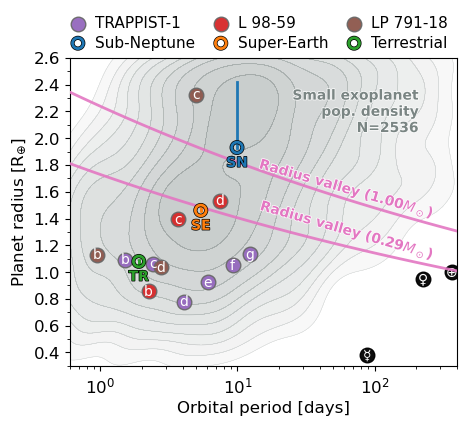

In [30]:
exo_raw = pd.read_csv(f"{THESIS_DIR}/data/exoplanet_eu.csv",delimiter=',')
exo_dat = exo_raw.loc[exo_raw['planet_status'] == 'Confirmed']

exo_named = [["TRAPPIST-1 b","TRAPPIST-1 c", "TRAPPIST-1 d", "TRAPPIST-1 e", "TRAPPIST-1 f", "TRAPPIST-1 g"],
             ["L 98-59 b", "L 98-59 c", "L 98-59 d", "L 98-59 e"],
            #  ["K2-18 b",],
             ["LP 791-18 b", "LP 791-18 c", "LP 791-18 d"],
            #  ["55 Cnc Ae"],
            #  ["TOI-270 d"]
            ]

exo_colors = [
    "tab:purple", "tab:red", "tab:brown", "blue", "grey", "green",
]

fig_ratio = tuple(np.array([4.2,4])*1.1)

named_s = 110     # point size
named_a = 0.95    # alpha
fs = 10      # font size

col_exoeu = "#7A8583"
# col_exoeu = 'tab:cyan'

leg_args = {
    "handletextpad" : 0.2,
    "frameon" :       False,
    "labelspacing":   0.3,
    "columnspacing":  0.8,
    "handlelength":   1.8
}

solar_sys_file = open(f"{THESIS_DIR}/data/solar_system.tsv",'r')
ss_lines = solar_sys_file.readlines()
solar_sys_file.close()

solar_system = {}

# Add bodies
for i,h in enumerate(ss_lines[1].split()[1:]):
    k = h.capitalize()
    solar_system[k] = {"index":i,"name":k}

# For each body
for k in solar_system.keys():
    i = solar_system[k]["index"]

    # For each parameter
    for l in ss_lines[2:]:
        split = l.split()
        param = str(split[0])
        val   = split[i+1]

        if (param == "Symbol"):
            solar_system[k]["symbol"] = str(val)
        else:
            val = float(val)
            match param:
                case "Mass(10^24kg)":
                    solar_system[k]["mass"] = val / 5.97  # M_earth
                case "Diameter(km)":
                    solar_system[k]["radius"] = val / 12756# R_earth
                case "MeanTemperature(C)":
                    solar_system[k]["temp_calculated"] =  val + 273.15 # K
                case "OrbitalPeriod(days)":
                    solar_system[k]["orbital_period"] = val   # day
                case "DistancefromSun(10^6km)":
                    solar_system[k]["semi_major_axis"] = val / 149.6  # AU
                case "OrbitalEccentricity":
                    solar_system[k]["eccentricity"] = val

fig,ax = plt.subplots(1,1,figsize=(5,4))

ax.set_xlabel("Orbital period [days]")
ax.set_xscale("log")
xlim = [0.6, 400]
ax.set_xlim(xlim)

ax.set_ylabel(r"Planet radius [R$_{\oplus}$]")
ylim = [0.3,2.6]
ax.set_ylim(ylim)
ax.yaxis.set_minor_locator(MultipleLocator(0.1))
ax.yaxis.set_major_locator(MultipleLocator(0.2))


exo_sub = deepcopy(exo_dat)
exo_mask = exo_sub["orbital_period"].between(xlim[0], xlim[1]) & exo_sub["radius"].between(ylim[0]*R_earth/R_jupiter, ylim[1]*R_earth/R_jupiter)
exo_sub = exo_sub.loc[exo_mask]
xv = exo_sub["orbital_period"].values
yv = exo_sub["radius"].values * R_jupiter / R_earth
_kde2d(ax, xv, yv, log_x=True, log_y=False, 
       col=col_exoeu, KDE_ALPHA_MAX=0.4,
       zorder=1, n_levels=10)
# ax.scatter(exo_sub["orbital_period"],exo_sub["radius"]* R_jupiter / R_earth,
        #    s=5, alpha=0.5, color='gray', edgecolors='none', rasterized=True)

for p in solar_system.values():

    # Skip some
    skip = ["Moon","Jupiter","Pluto","Saturn"]
    if (p["name"] in skip):
        continue

    x =  p["orbital_period"]
    y =  p["radius"]
    print(f"Solar system body {p['name']}: x={x:.2f}, y={y:.2f}")
    if not (ylim[0] <= y <=  ylim[1]):
        continue
    if not (xlim[0] <= x <=  xlim[1]):
        continue

    ax.scatter(x, y, s=named_s,     color='black',zorder=2, alpha=named_a)
    ax.text(x,    y, p["symbol"][0],color='white',zorder=4, horizontalalignment='center', verticalalignment='center', fontsize=fs)


for j,s in enumerate(exo_named):
    col = exo_colors[j]
    for i,p in enumerate(s):
        if i == 0:
            lbl = p[:-2]
        else:
            lbl = None
        row = exo_dat.loc[exo_dat['name'] == p].iloc[0]

        x = row["orbital_period"]
        y = row["radius"]* R_jupiter / R_earth

        a = ax.scatter(x,y, s=named_s, label=lbl, alpha=named_a, zorder=3, color=col, lw=1, ec='dimgrey')
        ax.text(x,y,p[-1],color='white',zorder=4, horizontalalignment='center', verticalalignment='center', fontsize=fs)

# Plot radius valley
#   https://academic.oup.com/mnras/article/519/3/4056/6969428
#   Equation 11
def radval(period, mass):
    logp = np.log10(period)
    logm = np.log10(mass)

    _RV_A, _RV_dA = -0.09, (0.02, 0.03)
    _RV_B, _RV_dB = 0.21, (0.06, 0.07)
    _RV_C, _RV_dC = 0.35, (0.02, 0.02)

    log_R = _RV_A * logp + _RV_B * logm + _RV_C
    return 10**log_R
M_star_gt = list(ground_truth.items())[0][1]["help"]["M_star"].iloc[0] / M_sun
x_rv = np.logspace(np.log10(xlim[0]), np.log10(xlim[1]), 60)

for M_star in [M_star_gt, 1.0]:
    y_rv = [radval(x, M_star) for x in x_rv]
    ax.plot(x_rv, y_rv, c='tab:pink', lw=2, alpha=0.9, zorder=4)
    ax.annotate(f"Radius valley ({M_star:.2f}" + r"$M_\odot$)", 
                xy=(x_rv[-5], y_rv[-5]), xytext=(0, 1), textcoords='offset points',
                zorder=4, fontweight='bold',
                path_effects=[pe.Stroke(linewidth=1, foreground='white'), pe.Normal()],
                color='tab:pink', fontsize=fs, rotation=-16, ha='right', va='bottom', rotation_mode='anchor')

# plot ground truth points
for suf, gt in ground_truth.items():
    gt_x = gt["help"]["orbital_period"] / (24*3600)
    gt_y = gt["help"]["R_obs"] / R_earth
    col = bo_cols[suf]
    ax.plot(gt_x, gt_y, zorder=5, color=col, lw=2)

    print(f"    initial: {gt_x.iloc[0]:.2f} days, {gt_y.iloc[0]:.2f} R_earth")
    print(f"    final:   {gt_x.iloc[-1]:.2f} days, {gt_y.iloc[-1]:.2f} R_earth")
    an_x = gt_x.iloc[-1]
    an_y = gt_y.iloc[-1]
    ax.scatter(an_x, an_y, s=60, lw=2,
               edgecolor=col, color='none', zorder=7,
               path_effects=[pe.Stroke(linewidth=3, foreground='k'), pe.Normal()],
               label=bo_tits[suf])

    ax.annotate(suf.upper(), xy=(an_x, an_y),
                xytext=(0, -6), textcoords='offset points',
                zorder=7,
                fontweight='bold', path_effects=[pe.Stroke(linewidth=1, foreground='k'), pe.Normal()],
                color=col, fontsize=fs, ha='center', va='top')

ax.text(0.9, 0.9, "Small exoplanet\npop. density\nN=%.0f" % len(exo_sub), 
        color=col_exoeu,
        transform=ax.transAxes, fontsize=fs, fontweight='bold', 
        ha='right', va='top', 
        path_effects=[pe.Stroke(linewidth=1, foreground='w'), pe.Normal()])

handles, labels = ax.get_legend_handles_labels()
handles = np.reshape(handles, (2,3)).T.flatten() # transpose legend
labels = np.reshape(labels, (2,3)).T.flatten()
leg = ax.legend(handles, labels, loc='lower left', bbox_to_anchor=(-0.05,0.98), **leg_args, ncols=3, fontsize=11)


fig.savefig("output/exoplanets.pdf", bbox_inches='tight', dpi=DPI, pad_inches=0.02)
plt.show()


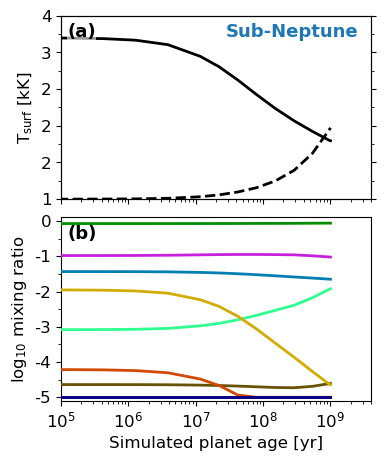

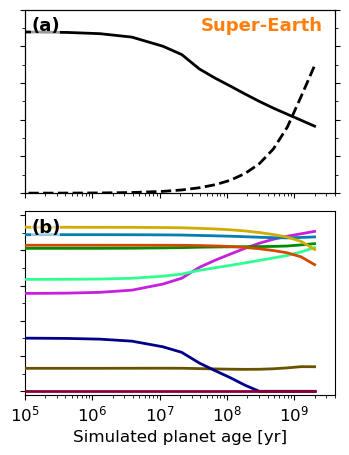

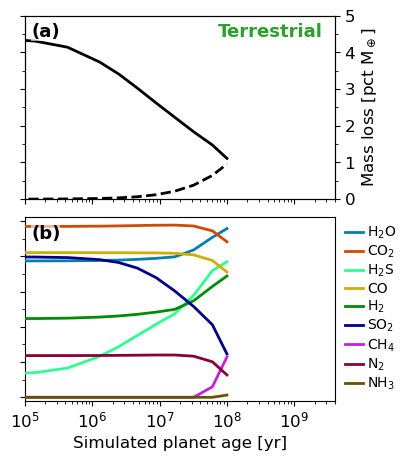

In [8]:
# plot variable over time for each GT run

abcd = 'abcdefg'
iax = 0
def plot_gt_evolve(suf, label_left=False, label_right=False):
    gt = ground_truth[suf]

    fig, axs = plt.subplots(2,1,figsize=(4,5), sharex=True)
    axt, axb = axs
    axtr = axs[0].twinx()

    # shared time-axis
    x = gt["help"]["Time"] # yr

    # top panel: temperature
    y = gt["help"]["T_surf"]/1e3
    axt.plot(x, y, zorder=5, color='k', lw=2)
    axt.set_ylim(1.0, 3.5)
    axt.yaxis.set_major_formatter(mpl.ticker.FormatStrFormatter("%.0f"))
    axt.yaxis.set_major_locator(MultipleLocator(0.5))
    axt.yaxis.set_minor_locator(MultipleLocator(0.25))
    if label_left:
        axt.set_ylabel(r"T$_{\rm surf}$ [kK]")
    else:
        axt.set_yticklabels([])

    # top right panel: integrated mass lost, from escape rate
    y = gt["help"]["esc_rate_total"] *100 \
        / M_earth * 365.25 * 24 * 3600 # Mearth% per yearr
    xinteg = x[3:] # yr
    yinteg = cumulative_simpson(y[3:], x=xinteg, initial=0) 
    axtr.plot(xinteg, yinteg, zorder=5, color='k', lw=2, ls='dashed')
    axtr.set_ylim(0, 5)
    axtr.yaxis.set_major_formatter(mpl.ticker.FormatStrFormatter("%.0f"))
    axtr.yaxis.set_major_locator(MultipleLocator(1))
    axtr.yaxis.set_minor_locator(MultipleLocator(0.5))
    if label_right:
        axtr.set_ylabel(r"Mass loss [pct M$_\oplus$]")
    else:
        axtr.set_yticklabels([])


    # bottom panel: log mixing ratios (sorted by abundance)
    gas_list_sorted = sorted(gas_list, key=lambda g: gt["help"][f"{g}_vmr"].iloc[-1], reverse=True)
    for gas in gas_list_sorted:
        l = latexify(gas)
        y = np.log10(np.clip(gt["help"][f"{gas}_vmr"], 1e-5, None))
        c = preset_colours.get(gas, preset_colours['_fallback'])
        axb.plot(x, y, zorder=5, color=c, lw=2, label=l)

    axb.set_ylim(-5.1, 0.1)
    axb.yaxis.set_major_formatter(mpl.ticker.FormatStrFormatter("%.0f"))
    axb.yaxis.set_major_locator(MultipleLocator(1))
    axb.yaxis.set_minor_locator(MultipleLocator(0.5))
    axb.set_xlabel("Simulated planet age [yr]")
    axb.set_xscale("log")
    axb.set_xlim(left=age_min, right=age_max)

    if label_left:
        axb.set_ylabel(r"log$_{10}$ mixing ratio")
    else:
        axb.set_yticklabels([])

    if label_right:
        axb.legend(loc='upper left', bbox_to_anchor=(1.01, 1.0), 
               frameon=False, fontsize=10,
               borderpad=0, handleheight=0.6,
               handletextpad=0.3, labelspacing=0.2, columnspacing=0.8, handlelength=1.3, 
               )

    # title
    bbox = dict(fc="w", ec="none", alpha=0.6, lw=1, pad=0)
    axtr.text(0.96, 0.96, bo_tits[suf], transform=axtr.transAxes,
                zorder=999, fontsize=13,
                color=bo_cols[suf], fontweight='bold', ha='right', va='top',
                bbox=bbox
                )

    # abc label
    for (iax, ax) in enumerate([axt, axb]):
        ax.text(0.02, 0.96, f"({chr(97 + iax)})", transform=ax.transAxes,
                fontsize=13, zorder=999, fontweight='bold', ha='left', va='top', bbox=bbox)

    fig.subplots_adjust(hspace=0.1)
    plt.show()

    fig.savefig(f"output/gt_evolve_{suf}.pdf", bbox_inches='tight', dpi=DPI, pad_inches=0.02)

for suf in list(ground_truth.keys()):
    label_left  = suf=='sn'
    label_right = suf=='tr'
    
    plot_gt_evolve(suf, label_left=label_left, label_right=label_right)

## Plot simulations resolving towards observables

In [9]:
print("\n".join(bo_data.keys()))

se.mat12.lei.5.100
sn.mat12.lei.5.100
tr.mat12.lei.5.100
tr.mat32.lei.5.100
tr.mat52.lei.5.100
tr.rbf.lei.5.100


Observables: ['R_obs', 'T_obs', 'g_obs', 'atm_kg_per_mol', 'C/O_atm', 'S/O_atm', 'O/H_atm']
R_obs
    sn   best objective for this BO: -0.34568817294240833
    se   best objective for this BO: -0.1990782243933466
    tr   best objective for this BO: 1.330308054574275
T_obs
    sn   best objective for this BO: -0.34568817294240833
    se   best objective for this BO: -0.1990782243933466
    tr   best objective for this BO: 1.330308054574275
g_obs
    sn   best objective for this BO: -0.34568817294240833
    se   best objective for this BO: -0.1990782243933466
    tr   best objective for this BO: 1.330308054574275
atm_kg_per_mol
    sn   best objective for this BO: -0.34568817294240833
    se   best objective for this BO: -0.1990782243933466
    tr   best objective for this BO: 1.330308054574275
C/O_atm
    sn   best objective for this BO: -0.34568817294240833
    se   best objective for this BO: -0.1990782243933466
    tr   best objective for this BO: 1.330308054574275
S/O_atm
    sn   

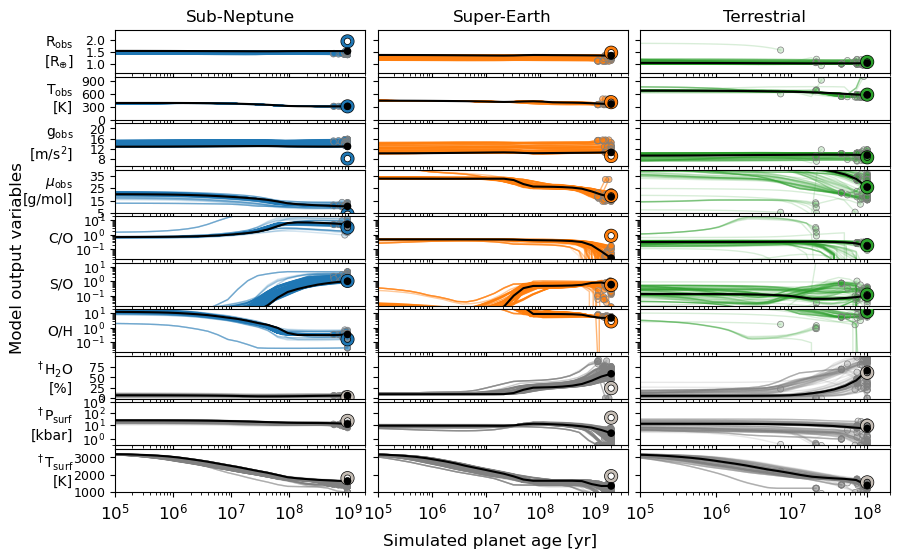

Done


In [44]:
def plot_bo_evolve():

    print("Observables:", obs_list)
    yvars = obs_list +['H2O_vmr', 'P_surf', 'T_surf']#, 'Phi_global']
    N_yv = len(yvars)

    show_cases = [f"{suf}.mat12.lei.5.100" for suf in ("sn","se","tr")]
    N_bo = len(show_cases)

    fig,axs = plt.subplots(N_yv,N_bo,figsize=(10,2+N_yv*0.4))

    # for each y-variable
    for iax in range(N_yv):
        key = yvars[iax]
        print(key)

        scale, yscl, ylim, ytck, ylbl_canonical = get_var_props(key)

        # for each BO run
        for jax, bo_key in enumerate(show_cases):
            suf = bo_key.split(".")[0]
            print("    "+suf, end='')

            ax = axs[iax, jax]

            bo = bo_data[bo_key]
            if bo is None:
                print(f"    BO run {bo_key} not found.")
                continue
            helps      = bo['helps']
            confs      = bo['confs']

            is_observable = key in obs_list
            col = bo_cols[suf]

            # get best objective value for this BO run
            best_obj = max(run['y_value'] for run in bo['log'])
            print("   best objective for this BO:", best_obj)

            # plot simulations from this BO run
            x_end = []
            y_end = []
            c_end = []
            for isim in range(len(helps)):
                help = helps[isim]
                conf = confs[isim]
                x = help['Time']
                y = help[key] / scale

                # value of objective (best=1)
                alp = max(0.2, bo['log'][isim]['y_value'] - best_obj+1) * 0.9

                if bo['is_best'][isim]:
                    col_sim = 'k'
                    lw_sim = 1.5
                    zorder_sim = 5
                    alp = 1.0
                else:
                    if is_observable:
                        col_sim = col
                    else:
                        col_sim = 'grey'
                    lw_sim = 1
                    zorder_sim = 1

                # sort x and remove duplicate times
                mask = np.argsort(x) & (x>1)
                x = np.array(x)[mask]
                y = np.array(y)[mask]

                # interpolate to get smoother lines
                if 3 < len(x) < 40:
                    x_plt = np.logspace(np.log10(min(x)), np.log10(max(x)), 40)
                    y_plt = PchipInterpolator(x, y)(x_plt)
                else:
                    x_plt = x
                    y_plt = y
                ax.plot(x_plt, y_plt, color=col_sim, alpha=alp, linewidth=lw_sim, zorder=zorder_sim)

                x_end.append(x[-1])
                y_end.append(y[-1])
                r,g,b = mpl.colors.to_rgb(col_sim)
                c_end.append((r, g, b, alp))

                # is best
                if bo['is_best'][isim]:
                    ax.scatter(x[-1], y[-1], color='k', edgecolor='none', s=30, zorder=21)

            # add scatter point at end of simulation
            ax.scatter(x_end, y_end, color=c_end, edgecolor='grey', s=20, lw=0.5, zorder=zorder_sim+1)

            # plot truths
            ylbl = ylbl_canonical
            if not is_observable:
                col = "#c6beb6"
                ylbl = r"$^\dagger$" + ylbl
            obs_tru = ground_truth[suf]['help'][key].iloc[-1] / scale
            obs_age = descend_get(ground_truth[suf]['config'], 'params.stop.time.maximum')
            ax.scatter(obs_age, obs_tru, color='none', edgecolor=col, s=50, zorder=20, lw=2,
                    path_effects=[pe.Stroke(linewidth=3, foreground='k'), pe.Normal()])

            ax.set_xscale("log")
            ax.set_xticks([1e3, 1e4, 1e5, 1e6, 1e7, 1e8, 1e9])
            ax.set_xlim(left=age_min, right=np.amax(x_end)*2.0)
            ax.set_ylim(ylim)
            ax.set_yscale(yscl)
            if ytck is not None:
                ax.set_yticks(ytck)
            if jax == 0:
                ax.set_ylabel(ylbl, rotation=0, 
                              labelpad=0,
                              ha='right', va='center', fontsize=10)
                ax.tick_params(axis='y', which='major', labelsize=9)
            else:
                ax.set_yticklabels([])

            if iax == 0:
                ax.set_title(bo_tits[suf], fontsize=font["size"])
            if iax == N_yv - 1:
                # ax.xaxis.set_major_formatter(mpl.ticker.FormatStrFormatter("%g"))
                pass
            else:
                ax.set_xticklabels([])

    ylabel = "Model output variables"
    fig.supylabel(ylabel, fontsize=font["size"])
    fig.supxlabel("Simulated planet age [yr]", va='top', fontsize=font["size"], y=0.04)
    fig.align_ylabels()
    fig.subplots_adjust(wspace=0.05, hspace=0.07)

    plt.show()
    fig.savefig("output/bo_evolve.pdf", bbox_inches='tight', dpi=DPI, pad_inches=0.01)

plot_bo_evolve()
print("Done")

## Plot retrieval resolving ground truth parameters

Parameters: ['interior_struct.core_frac', 'outgas.fO2_shift_IW', 'planet.elements.H_budget', 'planet.elements.C_budget', 'planet.elements.S_budget']
interior_struct.core_frac
     sn
     se
     tr
outgas.fO2_shift_IW
     sn
     se
     tr
planet.elements.H_budget
     sn
     se
     tr
planet.elements.C_budget
     sn
     se
     tr
planet.elements.S_budget
     sn
     se
     tr


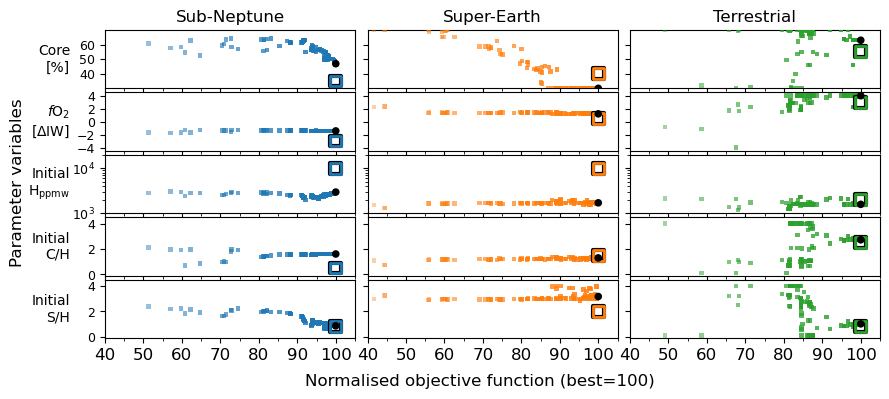

Done


In [43]:
def plot_bo_converge(xvar='clock'):
        
    print("Parameters:", prs_list)
    # prs_list.extend(["objective"])

    show_cases = [f"{suf}.mat12.lei.5.100" for suf in ("sn","se","tr")]

    N_pa = len(prs_list)
    N_bo = len(show_cases)

    fig,axs = plt.subplots(N_pa,N_bo,figsize=(10,2+N_pa*0.4))

    # for each parameter
    for iax in range(N_pa):
        key = prs_list[iax]
        print(key)

        scale, yscl, ylim, ytck, ylbl = get_var_props(key)
        if ylim is None:
            ylim = np.array([bo_data[show_cases[0]]['config']['parameters'][key]][0]) / scale

        # for each BO run
        global bo_suffixes
        for jax, bo_key in enumerate(show_cases):
            suf = show_cases[jax].split(".")[0]
            print("    ", suf)

            ax = axs[iax, jax]

            bo = bo_data[bo_key]
            log = bo['log']
            helps      = bo['helps']
            confs      = bo['confs']
            obs_this   = bo['obs']  # observables for this BO run
            prs_this   = bo['prs']  # parameters ranges for this BO run

            N_wk = np.amax([run['worker'] for run in log]) + 1
            col = bo_cols[suf]

            # get xmin from all cases
            tmin = np.inf
            xmax = -np.inf
            jbest = -np.inf
            jwrst = np.inf
            for isim in range(len(log)):

                jvalue = log[isim]['y_value']
                if jvalue < -19.9:
                    continue

                jbest = max(jbest, log[isim]['y_value'])
                jwrst = min(jwrst, log[isim]['y_value'])
                if xvar == 'clock':
                    tmin = min(tmin, log[isim]['start_time'])
                    

            # get values for each worker process
            for isim in range(len(log)):

                jvalue = log[isim]['y_value']
                if jvalue < -19.9:
                    continue

                jnorm = (jvalue - jwrst) / (jbest - jwrst) * 100

                if xvar == 'clock':
                    x0 = (log[isim]['start_time'] - tmin) / 60
                    x1 = (log[isim]['end_time'] - tmin) / 60
                    xmax = max(xmax, x1)
                    xfmt = "%.0f"
                    xlbl = "Retrieval clock time [minutes]"

                elif xvar == 'objective':
                    x0 = None
                    x1 = jnorm
                    xmax = max(xmax, x1)
                    xfmt = "%.0f"
                    xlbl = "Normalised objective function (best=100)"

                else:
                    raise ValueError(f"Unknown xvar '{xvar}'")

                yv = descend_get(confs[isim], key) / scale
                alp = max(0.1, jnorm/100) * 0.9

                if x0 is not None:
                    ax.plot([x0,x1], [yv, yv], color=col, alpha=alp, zorder=10, lw=0.5, linestyle='-')
                ax.scatter(x1, yv, color=col, alpha=alp, edgecolor='none',
                        s=10, zorder=10, lw=0.5, marker='s')

                # is best?
                if bo['is_best'][isim]:
                    ax.scatter(x1, yv, color='k', edgecolor='none', s=30, zorder=101)

            # plot true value on this parameter
            par_tru = descend_get(ground_truth[suf]['config'],key)/scale
            ax.scatter(xmax, par_tru, marker='s', color='none', edgecolor=col, s=60, zorder=100, lw=2,
                    path_effects=[pe.Stroke(linewidth=3, foreground='k'), pe.Normal()])
            
            
            ax.set_ylim(ylim)
            ax.set_yscale(yscl)
            if ytck is not None:
                ax.set_yticks(ytck)
            if jax == 0:
                ax.set_ylabel(ylbl, rotation=0, labelpad=1.5,
                              ha='right', va='center', fontsize=10)
                ax.tick_params(axis='y', which='major', labelsize=9)
            else:
                ax.set_yticklabels([])


            if xvar == 'objective':
                ax.xaxis.set_major_locator(MultipleLocator(10))
                ax.xaxis.set_minor_locator(MultipleLocator(5))
                xmin = 40
                xmax = 100
            elif xvar == 'clock':
                xmin = -0.1
            else:
                raise ValueError(f"Unknown xvar '{xvar}'")
            ax.set_xlim(xmin, xmax*1.05)
            if iax == 0:
                ax.set_title(bo_tits[suf], fontsize=font["size"])
            if iax == N_pa - 1:
                ax.xaxis.set_major_formatter(mpl.ticker.FormatStrFormatter(xfmt))
                pass
            else:
                ax.set_xticklabels([])

    fig.supylabel("Parameter variables", fontsize=font["size"], x=0.03)

    fig.supxlabel(xlbl, va='top', fontsize=font["size"], y=0.02)
    fig.align_ylabels()
    fig.subplots_adjust(wspace=0.05, hspace=0.07)

    plt.show()
    fig.savefig(f"output/bo_converge_{xvar}.pdf", bbox_inches='tight', dpi=DPI, pad_inches=0.01)

# plot_bo_converge('clock')
plot_bo_converge('objective')
print("Done")

## Parameter-observable correlations across all scenarios

In [12]:

def plot_corner():

    corner_prs = deepcopy(prs_list)

    corner_obs = deepcopy(obs_list)

    N_pa = len(corner_prs)
    N_ob = len(corner_obs)

    fig, axs = plt.subplots(N_ob, N_pa, figsize=(2+0.7*N_pa,2+0.7*N_ob))

    for ipar,par in enumerate(corner_prs):
        for iobs,obs in enumerate(corner_obs):
            ax = axs[iobs, ipar]

            scale_p, scl_p, lim_p, tck_p, lbl_p = get_var_props(par)
            scale_o, scl_o, lim_o, tck_o, lbl_o = get_var_props(obs)

            # for each bo run
            for jax, suf in enumerate(bo_suffixes):
                bo       = bo_data[suf]
                log      = bo['log']
                confs    = bo['confs']
                obs_this = bo['obs']  # observables for this BO run
                helps    = bo['helps']
                col = bo_cols[suf]

                xarr, yarr = [], []
                for isim in range(len(log)):
                    xarr.append(descend_get(confs[isim], par) / scale_p)
                    yarr.append(helps[isim][obs].iloc[-1] / scale_o)
                ax.scatter(xarr, yarr, color=col, alpha=0.35, edgecolor='none', s=4, zorder=10)

                # truth
                # par_tru = descend_get(ground_truth[suf]['config'], par) / scale_p
                # obs_tru = ground_truth[suf]['help'][obs].iloc[-1] / scale_o
                # ax.scatter(par_tru, obs_tru, marker='s', color='none', edgecolor=col, s=60, zorder=100, lw=2,
                #            path_effects=[pe.Stroke(linewidth=3, foreground='k'), pe.Normal()])

            # left column
            ax.set_yscale(scl_o)
            ax.set_yticks(tck_o)
            if ipar == 0:
                ax.set_ylabel(lbl_o, rotation=0, ha='right', va='center', fontsize=10)
                ax.tick_params(axis='y', which='major', labelsize=9)
            else:
                ax.set_yticklabels([])

            # bottom row
            ax.set_xscale(scl_p)
            if tck_p is not None:
                ax.set_xticks(tck_p)
            if iobs == N_ob - 1:
                ax.set_xlabel(lbl_p, rotation=0, ha='center', va='top', fontsize=10)
                ax.tick_params(axis='x', which='major', labelsize=9)
            else:
                ax.set_xticklabels([])

    fig.align_ylabels()
    fig.supylabel("Observables", fontsize=11)
    fig.supxlabel("Parameters",  fontsize=11)

    fig.subplots_adjust(wspace=0.05, hspace=0.05)
    fig.savefig("output/bo_corr.pdf", bbox_inches='tight', dpi=DPI, pad_inches=0.01)
    plt.show()

# plot_corner()

## SN with/without certain parameters

In [13]:
def plot_bo_time_orbit():
    cases = ["sn_time", "sn_orbit"]
    stys = ["s", "^"]
    cols = ['tab:purple', 'tab:red']

    fig, axs = plt.subplots(2,1,figsize=(5,3.5), sharex=True)

    y_keys = ["params.stop.time.maximum", "orbit.semimajoraxis"]
    x_key = "delivery.elements.H_oceans"
    xscale, xscl, xlim, xtck, xlbl = get_var_props(x_key)

    for iax,ax in enumerate(axs):

        y_key = y_keys[iax]
        scale, yscl, ylim, ytck, ylbl = get_var_props(y_key)
        print(iax, y_keys[iax])

        jbest = -np.inf

        # add baseline 'sn' run
        confs = bo_data['sn']['confs']
        log = bo_data['sn']['log']
        xarr = []
        yarr = []
        jarr = []
        for isim in range(len(log)):
            xarr.append(descend_get(confs[isim], x_key) / xscale)
            yarr.append(descend_get(confs[isim], y_key) / scale)
            jarr.append(log[isim]['y_value'])

            if bo_data['sn']['is_best'][isim]:
                xbest = xarr[-1]
                ybest = yarr[-1]

        jbest = np.amax(jarr)
        jarr = np.clip(jarr-jbest+1, 0.2, 1.0) * 0.9
        
        col_base = bo_cols['sn']

        # plot baseline
        ax.scatter(xarr, yarr, color=col_base,
                alpha=jarr**2,  zorder=10, marker='o', s=20)

        besti = np.argwhere(bo_data['sn']['is_best'])[0][0]
        bestx = xarr[besti]
        besty = yarr[besti]
        stdx  = np.std(xarr)/np.sqrt(len(xarr))
        print(f"Best baseline SN: {bestx:.2e}, {besty:.2e}")

        # legend entry for baseline
        lbl = "Baseline SN\n"
        lbl += r"H$_{\rm oc} \Rightarrow$" + f"{bestx:.0f}" +  r"$\pm$" + f"{stdx:.0f}"
        ax.scatter([], [], color=col_base, label=lbl, marker='o', s=50)

        # add comparison BO runs
        for jax, suf in enumerate(cases):
            bo_dir = f"{SIM_DIR}/bayesopt_infer_{suf}/"
            print(bo_dir)
            bo = get_bo_run(bo_dir)

            if bo is None:
                print(f"BO run not found for case {suf}, skipping.")
                continue

            col      = cols[jax]
            log      = bo['log']
            confs    = bo['confs']
            obs_this = bo['obs']  # observables for this BO run
            helps    = bo['helps']

            marker = stys[jax]

            xarr = []
            yarr = []
            jarr = []
            for isim in range(len(log)):
                xarr.append(descend_get(confs[isim], x_key) / xscale)
                yarr.append(descend_get(confs[isim], y_key) / scale)
                jarr.append(log[isim]['y_value'])
            jarr = np.clip(jarr-jbest+1, 0.2, 1.0) * 0.9

            # plot data for this BO run
            ax.scatter(xarr, yarr, color=col, alpha=jarr,  zorder=10,
                            s=20, marker=marker, edgecolor='none')

            besti = np.argwhere(bo['is_best'])[0][0]
            bestx = xarr[besti]
            besty = yarr[besti]
            stdx  = np.std(xarr)/np.sqrt(len(xarr))
            print(f"Best {suf}: {bestx:.2e}, {besty:.2e}")

            # legend entry for this BO run
            if suf == "sn_time":
                lbl = "Age varied\n"
                lbl += r"H$_{\rm oc} \Rightarrow$" + f"{bestx:.0f}" +  r"$\pm$" + f"{stdx:.0f}"
            elif suf == "sn_orbit":
                lbl = "Orbit varied\n"
                lbl += r"H$_{\rm oc} \Rightarrow$" + f"{bestx:.0f}" +  r"$\pm$" + f"{stdx:.0f}"
            else:
                raise ValueError(f"Unknown case {suf}")
            ax.scatter([], [], color=col, label=lbl, marker=marker, s=50)


        # plot truth and decorate
        bo_tru_y = descend_get(ground_truth['sn']['config'], y_key) / scale
        ax.axhline(bo_tru_y,   color='k', lw=1, alpha=0.8, zorder=1)

        bo_tru_x = descend_get(ground_truth['sn']['config'], x_key) / xscale
        ax.axvline(bo_tru_x,   color='k', lw=1, alpha=0.8, zorder=1)

        ax.scatter(bo_tru_x, bo_tru_y, marker='o', color='none',
                edgecolor='k', s=60, zorder=100, lw=2, alpha=0.9)

        lbl = "Truth\n"
        lbl += r"H$_{\rm oc}$" + f"={bo_tru_x:.0f}"
        ax.annotate(lbl, xy=(bo_tru_x, bo_tru_y), xytext=(-3, -3), textcoords='offset points',
                    color='k', fontsize=10, ha='right', va='top')

        ax.set_ylabel(ylbl, rotation=0, ha='right', va='center', fontsize=10)
        ax.set_ylim(ylim)
        ax.set_yscale(yscl)

    # legend
    axs[0].legend(loc='lower center', bbox_to_anchor=(0.5,1), ncols=3, fontsize=10,
                    edgecolor='none', framealpha=1.0,
                    borderpad=0, handletextpad=0.2, labelspacing=0.3, columnspacing=1.5,
                    handlelength=1.0)

    # decorate
    axs[-1].yaxis.set_major_locator(MultipleLocator(0.05))
    axs[-1].yaxis.set_minor_locator(MultipleLocator(0.01))

    axs[-1].set_xlim(100, 900)
    axs[-1].xaxis.set_major_locator(MultipleLocator(100))
    axs[-1].xaxis.set_minor_locator(MultipleLocator(20))

    axs[-1].set_xlabel(xlbl, fontsize=font["size"])

    fig.subplots_adjust(hspace=0.02)
    plt.show()
    fig.savefig("output/bo_corr.pdf", bbox_inches='tight', dpi=DPI, pad_inches=0.01)

# plot_bo_time_orbit()

## Planet using different ACQF, Kernel, and CPUs

In [14]:
bo_cache = {}

Baseline parameters:
  Suffix: tr
  Acquisition function: lei
  Kernel: mat12
  Workers: 5
  Steps: 100
        best worker: [91] with y = 1.379608038117538
data/bayesopt_recent//bayesopt_infer_tr_mat12_ucb_5_100/
	 output/bayesopt_tr/init_coupler.toml
        best worker: [68] with y = 1.330308054574275
data/bayesopt_recent//bayesopt_infer_tr_mat12_lei_5_100/
	 output/bayesopt_tr/init_coupler.toml
        best worker: [92] with y = -0.13736095195848055
data/bayesopt_recent//bayesopt_infer_tr_mat12_lpi_5_100/
	 output/bayesopt_tr/init_coupler.toml
Best objective for ACQF: 1.38 at 91.5 s
Worst objective for ACQF: -2.00
        best worker: [13] with y = -0.05339839844368909
data/bayesopt_recent//bayesopt_infer_tr_rbf_lei_5_100/
	 output/bayesopt_tr/init_coupler.toml
data/bayesopt_recent//bayesopt_infer_tr_mat12_lei_5_100/
	 output/bayesopt_tr/init_coupler.toml
        best worker: [43] with y = 0.7244887940872834
data/bayesopt_recent//bayesopt_infer_tr_mat32_lei_5_100/
	 output/bayesopt

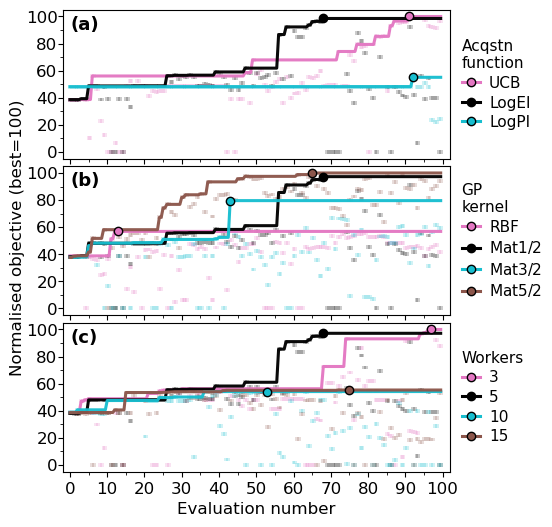

In [15]:
# load different BO runs for different settings

acq_map = {
    'ucb': ("UCB", 'tab:pink'),
    'lei': ("LogEI", 'black'),
    'lpi': ("LogPI", 'tab:cyan'),
}

ker_map = {
    'rbf': ("RBF", 'tab:pink'),
    'mat12': (r"Mat$1/2$", 'black'),
    'mat32': (r"Mat$3/2$", 'tab:cyan'),
    'mat52': (r"Mat$5/2$", 'tab:brown'),
}

cpu_map = {
    '3': ("3", 'tab:pink'),
    '5': ("5", 'black'),
    '10': ("10", 'tab:cyan'),
    '15': ("15", 'tab:brown')
}

style_map = {
    'ACQF': ("Acqstn\nfunction", acq_map),
    'Kernel': ("GP\nkernel", ker_map),
    'Workers': ("Workers", cpu_map)
}

ymin = 0
ls = 'solid'

# baseline parameters
bl_suf = 'tr'
bl_acq = 'lei'
bl_ker = 'mat12'
bl_wrk = '5'
bl_stp = '100'

print("Baseline parameters:")
print(f"  Suffix: {bl_suf}")
print(f"  Acquisition function: {bl_acq}")
print(f"  Kernel: {bl_ker}")
print(f"  Workers: {bl_wrk}")
print(f"  Steps: {bl_stp}")

hyperpar_list = list(style_map.keys())
Nax = len(hyperpar_list)

fig,axs = plt.subplots(Nax,1,figsize=(5,Nax*2))

for iax, hyperpar in enumerate(hyperpar_list):
    ax = axs[iax]

    # determine best and worst objective
    jbest = -np.inf
    jwrst = np.inf
    jclip = -2
    xbest = 0
    kbest = None
    for hyperpar_val in style_map[hyperpar][1].keys():

        # baseline hyperparameters
        suf = bl_suf
        acq = bl_acq
        ker = bl_ker
        wrk = bl_wrk
        stp = bl_stp

        # set hyperparameter to vary
        if hyperpar == 'ACQF':
            acq = hyperpar_val
        elif hyperpar == 'Kernel':
            ker = hyperpar_val
        elif hyperpar == 'Workers':
            wrk = hyperpar_val

        bo_dir = f"{SIM_DIR}/bayesopt_infer_{suf}_{ker}_{acq}_{wrk}_{stp}/"
        if bo_dir in bo_cache:
            bo = bo_cache[bo_dir]
        else:
            bo = get_bo_run(bo_dir)
        if bo is None:
            print(f"BO run not found for {acq} with {wrk} CPUs")
            continue

        bo_cache[bo_dir] = bo
        print(bo_dir)
        print("\t",bo['config']['ref_config'])

        log        = bo['log']
        for isim in range(len(log)):
            yv = log[isim]['y_value']
            if yv < -19.9:
                continue
            yv = max(yv, jclip)
            jwrst = min(jwrst, yv)
            if yv > jbest:
                jbest = yv
                xbest = isim + 0.5
                kbest = hyperpar_val
        
    print(f"Best objective for {hyperpar}: {jbest:.2f} at {xbest} s")
    print(f"Worst objective for {hyperpar}: {jwrst:.2f}")

    for hyperpar_val in style_map[hyperpar][1].keys():

        # baseline hyperparameters
        suf = bl_suf
        acq = bl_acq
        ker = bl_ker
        wrk = bl_wrk
        stp = bl_stp

        # set hyperparameter to vary
        if hyperpar == 'ACQF':
            acq = hyperpar_val
        elif hyperpar == 'Kernel':
            ker = hyperpar_val
        elif hyperpar == 'Workers':
            wrk = hyperpar_val

        # ncpu = int(wrk)
        ncpu = 1

        lbl = style_map[hyperpar][1][hyperpar_val][0]
        col = style_map[hyperpar][1][hyperpar_val][1]

        # get data        
        bo_dir = f"{SIM_DIR}/bayesopt_infer_{suf}_{ker}_{acq}_{wrk}_{stp}/"
        if bo_dir not in bo_cache:
            print(f"BO run not found for {acq} with {wrk} CPUs")
            continue
        bo = bo_cache[bo_dir]
        log        = bo['log']
        helps      = bo['helps']
        confs      = bo['confs']
        obs_this   = bo['obs']  # observables for this BO run
        prs_this   = bo['prs']  # parameters ranges for this BO run

        # get values for each worker process
        xarr, yarr = [], []
        for isim in range(len(log)):
            yv = log[isim]['y_value']
            if yv < -19.9:
                continue
            yv = max(yv, jclip)
            yv = (yv - jwrst) / (jbest - jwrst) * 100

            t0 = isim
            t1 = isim + 0.5

            # calculate time with nCPUs
            t0 = t0*ncpu
            t1 = t1*ncpu

            xarr.extend([t0, t1])
            yarr.extend([yv, yv])

        yarr = np.clip(yarr, jclip, None)
        xarr = np.array(xarr)

        # scatter all the data
        ax.scatter(xarr, yarr, color=col, alpha=0.2, edgecolor='none',
                       s=8, zorder=10, lw=1, marker='s')

        # line plot showing max over time
        mask = np.argsort(xarr)
        xarr = xarr[mask]
        yarr = yarr[mask]
        yarr = np.maximum.accumulate(yarr)
        ax.plot(xarr, yarr, color=col, alpha=0.96, lw=2.2, zorder=20, linestyle=ls)

        # best point for this combination of hyperparameters
        ibest = np.argmax(yarr)
        ax.plot([xarr[ibest]], [yarr[ibest]], color=col, markeredgecolor='k',
                   markersize=6, zorder=30, lw=2.2, marker='o', label=lbl)

    ax.legend(loc='center left', bbox_to_anchor=(1.01,0.5), 
              title=style_map[hyperpar][0], title_fontsize=11, alignment='left',
               handlelength=1.2, handletextpad=0.6, labelspacing=0.3, columnspacing=1.5,
                fontsize=11, framealpha=1.0, edgecolor='none', borderpad=0)

    # for (ann_s, ann_x) in [("soon", 0.03), ("late", 0.97)]:
    #     for (ann_l, ann_y) in [("Good", 0.97), ("Bad", 0.03)]:
    #         ha = 'left' if ann_x < 0.5 else 'right'
    #         va = 'top' if ann_y > 0.5 else 'bottom'
    #         txt = f"{ann_l}, {ann_s}"

    #         ax.text(ann_x, ann_y, txt, transform=ax.transAxes, fontsize=11, ha=ha, va=va, zorder=99,
    #             color='k')

    # ax.set_ylim(-5, 105)
    ax.yaxis.set_major_locator(MultipleLocator(20))
    ax.yaxis.set_minor_locator(MultipleLocator(10))
    ax.yaxis.set_major_formatter(mpl.ticker.FormatStrFormatter("%.0f"))
    ax.tick_params(axis='y', which='major', pad=0.1, labelsize=font["size"])

    ax.set_xlim(left=-2, right=102)
    ax.xaxis.set_major_locator(MultipleLocator(10))
    ax.xaxis.set_minor_locator(MultipleLocator(5))

    # ax.grid(which='major', axis='x', alpha=0.5, lw=0.8)

    if iax < Nax - 1:
        ax.set_xticklabels([])
    else:
        ax.set_xlabel("Evaluation number")

    abcd = 'abcdefghijklmnopqrstuvwxyz'
    bbox = dict(facecolor='white', edgecolor='none', alpha=0.9, pad=0.0)
    ax.text(0.02, 0.96, f"({abcd[iax]})", 
            transform=ax.transAxes,  fontweight='bold',
            fontsize=13, ha='left', va='top',
            bbox=bbox)


fig.supylabel("Normalised objective (best=100)", fontsize=font["size"])
fig.subplots_adjust(hspace=0.05)
fig.savefig("output/bo_perf.pdf", bbox_inches='tight', dpi=DPI, pad_inches=0.01)
plt.show()

## PROTEUS runtimes histograms

     sn
sn.mat12.lei.5.100
     se
se.mat12.lei.5.100
     tr
tr.mat12.lei.5.100


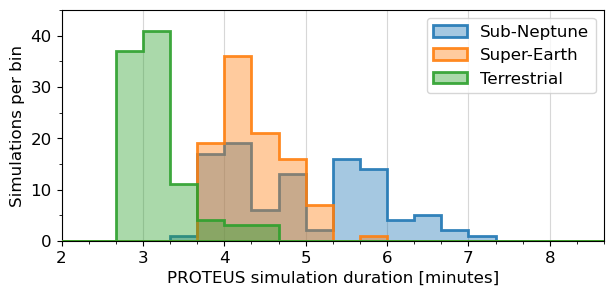

In [16]:
def plot_runtime_stats():

    show_cases = [f"{suf}.mat12.lei.5.100" for suf in ("sn","se","tr")]

    Nax = len(show_cases)

    fig,ax = plt.subplots(1,1,figsize=(7,3))

    dx = 20
    bins = np.arange(2, 9, dx/60.0)

    ymax = 1

    # for each BO run
    global bo_suffixes
    for iax, bo_key in enumerate(show_cases):
        suf = show_cases[iax].split(".")[0]
        print("    ", suf)

        bo = bo_data[bo_key]
        print(bo_key)
        log = bo['log']
        helps      = bo['helps']
        confs      = bo['confs']
        obs_this   = bo['obs']  # observables for this BO run
        prs_this   = bo['prs']  # parameters ranges for this BO run

        col = bo_cols[suf]

        # get values for each worker process
        clocktimes = []
        for isim in range(len(log)):
            clocktimes.append(log[isim]['end_time'] - log[isim]['start_time'])
        clocktimes = np.array(clocktimes) / 60  # convert to minutes


        fc = mpl.colors.to_rgba(col, alpha=0.4)
        ec = mpl.colors.to_rgba(col, alpha=0.9)
        n, bins, patches = ax.hist(clocktimes, bins=bins, color=fc, 
                                        histtype='stepfilled',
                                        label=bo_tits[suf],
                                        zorder=4, 
                                        edgecolor=ec, 
                                        lw=2)

        ymax = max(ymax, np.amax(n))

    ax.legend()
    ax.grid(zorder=-2, alpha=0.5, axis='x')

    ax.set_ylabel("Simulations per bin")
    ax.set_ylim(0, ymax*1.1)
    ax.yaxis.set_major_locator(mpl.ticker.MultipleLocator(10))
    ax.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(5))
    
    ax.set_xlim(np.amin(bins), np.amax(bins))
    ax.xaxis.set_major_locator(mpl.ticker.MultipleLocator(1))
    ax.xaxis.set_minor_locator(mpl.ticker.MultipleLocator(dx/60))
    ax.set_xlabel("PROTEUS simulation duration [minutes]", fontsize=font["size"])

    fig.subplots_adjust(wspace=0.05, hspace=0.05)
    plt.show()
    fig.savefig(f"output/bo_behave_runtime.pdf", bbox_inches='tight', dpi=DPI, pad_inches=0.01)

plot_runtime_stats()